# Student Placement Prediction

## 1) Problem Statement

* The objective of this project is to build a machine learning model that predicts whether a student will be placed based on academic performance, technical skills, and practical experience.

* Early identification of students with lower placement probability can help universities provide targeted support such as additional training, internships, or skill development programs.

* The dataset includes various student attributes such as CGPA, coding skills, internship experience, project count, and technical knowledge scores. Using these features, we aim to train and evaluate multiple machine learning models to determine the factors that most strongly influence placement outcomes.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.extras import column_stack

df = pd.read_csv(r'C:\Users\User\PyCharmMiscProject\Datasets\student_placement_synthetic.csv')
df.info() #


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

## 2) Dataset Overview

The dataset contains **100,000 student records** with **18 features** describing academic performance, technical skills, and extracurricular experience.

### Key Feature Categories

df.iloc[:,:-2] 16 Feature variables

### Target Variables

- **placement_status** → Binary classification target (1 = placed, 0 = not placed)
- **salary_package_lpa** → Regression target representing annual salary (only available for placed students)

Since salary is only available for placed students, the primary focus of this project is **placement prediction (classification)**.

In [2]:
x = df.iloc[:,:-2] # 16 features variables
y = df["placement_status"] # 1 class target variable

In [3]:
df.isna().sum() #We ignore salary_package_lpa because since salary is only for placed students
df.duplicated().sum()

np.int64(0)

## 3) Exploratory Data Analysis

### Observations

Initial analysis shows that the dataset is moderately imbalanced:

- **Placed students:** ~69%
- **Not placed students:** ~31%

This imbalance may affect model training and evaluation, making metrics such as **precision, recall, and F1-score** more informative than accuracy alone.

EDA visualizations such as boxplots, histograms, and correlation heatmaps help reveal how features like **CGPA, coding skills, and internship experience** relate to placement success.

In [ ]:
sns.countplot(x=df["placement_status"])
plt.show()

In [ ]:
sns.boxplot(x="placement_status", y="cgpa", data=df)
plt.show()

In [ ]:
sns.boxplot(x="placement_status", y="internships", data=df)
plt.show()

In [ ]:
sns.boxplot(x="placement_status", y="coding_skills", data=df)
plt.show()

## 4) Data Preprocessing


- #### NO missing and duplicated since we only considered placement_status!

- #### Used Label Encoding The categorical variables `branch` and `college_tier`

- ####  Feature selection (VIF) and (RFECV)




In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in x.columns:
    if x[col].dtypes == "object":
        x[col] = le.fit_transform(x[col])


In [ ]:
plt.figure(figsize = (20, 10))
sns.heatmap(x.corr(), annot=True, cmap="rocket")
plt.show()

## 5) Here we train and test model without VIF and RFECV
#### Then compare which phase is good one or two?

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### PIPELINE HAS USED!!!

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model_lr', LogisticRegression(class_weight="balanced", C=10, max_iter=10000))
])

pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model_lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not 

In [13]:
y_prob = pipeline.predict_proba(x_test)[:,1]
y_prob

array([0.56733909, 0.81600437, 0.36011005, ..., 0.41414318, 0.55155967,
       0.67720548], shape=(20000,))

In [14]:
y_pred = pipeline.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [15]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.65      0.53      6335
           1       0.79      0.62      0.70     13665

    accuracy                           0.63     20000
   macro avg       0.62      0.64      0.61     20000
weighted avg       0.68      0.63      0.64     20000



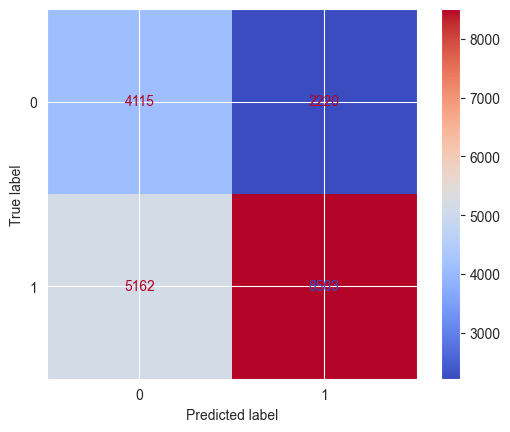

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='coolwarm')
plt.show()

## 6) VIF and RFECV used for features selection!

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data


,features,vif
2,cgpa,37.619747
6,aptitude_score,25.117779
7,communication_skills,15.420088
4,coding_skills,15.353275
5,dsa_score,9.930017
8,ml_knowledge,6.051708
9,system_design,5.904003
11,projects_count,4.613150
1,college_tier,4.207098
0,branch,3.153675


In [18]:
x.drop(["cgpa"], axis=1, inplace=True)

In [19]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
5,aptitude_score,21.250254
6,communication_skills,14.245837
3,coding_skills,14.189269
4,dsa_score,9.500662
7,ml_knowledge,5.915355
8,system_design,5.766411
10,projects_count,4.532912
1,college_tier,4.190541
0,branch,3.123676
11,certifications,2.762486


In [20]:
x.drop(["aptitude_score"], axis=1, inplace=True)

In [21]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
3,coding_skills,13.011055
5,communication_skills,13.002504
4,dsa_score,9.047948
6,ml_knowledge,5.771089
7,system_design,5.632067
9,projects_count,4.458086
1,college_tier,4.126079
0,branch,3.093249
10,certifications,2.739535
13,extracurriculars,2.370698


In [22]:
x.drop(["coding_skills"], axis=1, inplace=True)


In [23]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
vif_data

,features,vif
4,communication_skills,11.808934
3,dsa_score,8.596391
5,ml_knowledge,5.623395
6,system_design,5.487648
8,projects_count,4.382410
1,college_tier,4.061300
0,branch,3.063334
9,certifications,2.711844
12,extracurriculars,2.353893
7,internships,2.300222


In [24]:
x.drop(["communication_skills"], axis=1, inplace=True)

In [25]:
vif_data = pd.DataFrame()
vif_data["features"] = x.columns
vif_data["vif"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif_data.sort_values(by="vif", ascending=False, inplace=True)
print(vif_data["features"])

3                     dsa_score
4                  ml_knowledge
5                 system_design
7                projects_count
1                  college_tier
0                        branch
8                certifications
11             extracurriculars
6                   internships
9                    hackathons
10    open_source_contributions
2                      backlogs
Name: features, dtype: object


### VIF selected columns are,
- dsa_score
- ml_knowledge
- system_design
- projects_count
- college_tier
- branch
- certifications
- extracurriculars
- internships
- hackathons
- open_source_contributions
- backlogs

In [49]:
x1 = df[["dsa_score",
'ml_knowledge',
'system_design',
'projects_count',
'college_tier',
 'branch',
'certifications',
 'extracurriculars',
'internships',
'hackathons',
'open_source_contributions',
'backlogs']]# x1 is vif selected columns

y_reg = df["salary_package_lpa"]
y_cal = df["placement_status"]
y_cal

0        1
1        0
2        1
3        0
4        1
        ..
99995    0
99996    1
99997    1
99998    1
99999    1
Name: placement_status, Length: 100000, dtype: int64

In [52]:
x1

,dsa_score,ml_knowledge,system_design,projects_count,college_tier,branch,certifications,extracurriculars,internships,hackathons,open_source_contributions,backlogs
0,4.4,6.4,0.3,4,2,3,4,1,1,3,2,0
1,7.9,6.3,1.9,4,1,2,0,0,0,0,0,0
2,6.8,4.4,5.2,3,1,4,2,0,1,1,2,0
3,3.1,1.1,6.7,4,1,0,3,0,1,0,0,0
4,4.7,2.7,2.8,2,1,1,0,1,1,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,5.4,9.1,3.8,3,2,5,2,3,2,0,0,0
99996,6.8,5.6,2.4,2,2,5,3,0,1,0,1,0
99997,9.1,3.5,5.2,2,1,4,1,2,0,0,1,0
99998,8.0,6.2,0.2,4,2,6,2,1,1,0,0,0


In [53]:
from sklearn.model_selection import train_test_split
x1_train, x1_test, y_train, y_test = train_test_split(x1, y, test_size=0.2, random_state=42)

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
le1 = LabelEncoder()


model_lr = LogisticRegression()
pipeline1 = Pipeline([
    ('scaler', StandardScaler()),
    ('model_lr', LogisticRegression(class_weight="balanced", max_iter=10000, C=10))
])

pipeline1.fit(x1_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model_lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not 

In [55]:
y1_pred = pipeline1.predict(x1_test)
y1_pred

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [56]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y1_pred))

              precision    recall  f1-score   support

           0       0.42      0.64      0.51      6335
           1       0.78      0.59      0.67     13665

    accuracy                           0.61     20000
   macro avg       0.60      0.62      0.59     20000
weighted avg       0.67      0.61      0.62     20000



### For "salary_package_lpa" we might need to use Linear Regression() because output is continuous

### But for "placement_status" we summon multiple models for comparison between Logistic and trees based model which act well!?


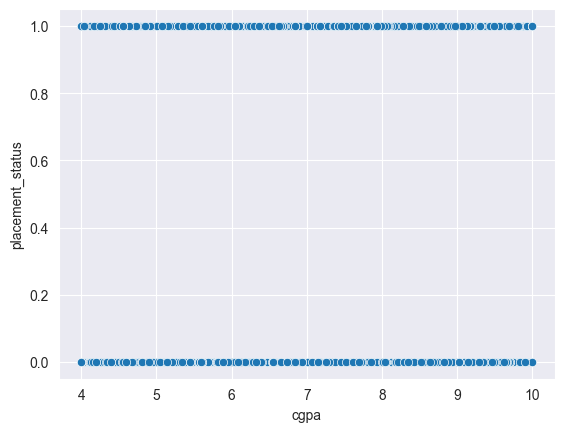

In [118]:
sns.scatterplot(x=df["cgpa"], y= y_cal)
plt.show()

In [117]:
df.corr()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
branch,1.000000,0.001150,-0.001580,0.000006,-0.002858,0.000479,-0.000832,0.004744,-0.004135,-0.001908,-0.000255,0.002272,0.002527,-0.005863,0.000148,-0.003600,-0.001470,-0.006789
college_tier,0.001150,1.000000,-0.233985,0.003982,-0.001498,-0.001532,0.000048,0.000336,0.004777,-0.003005,-0.000177,-0.008472,0.003996,0.001281,-0.001658,-0.001402,-0.180052,-0.356266
cgpa,-0.001580,-0.233985,1.000000,-0.003757,-0.006737,-0.001525,0.000108,-0.000479,-0.004248,0.004056,0.000280,0.002458,-0.002141,0.002199,0.001281,0.000351,0.148932,0.337110
backlogs,0.000006,0.003982,-0.003757,1.000000,-0.002605,0.000614,-0.002761,0.002711,0.003838,-0.004868,-0.001612,0.002540,-0.004352,0.002331,0.002909,-0.000220,-0.058815,0.007919
coding_skills,-0.002858,-0.001498,-0.006737,-0.002605,1.000000,-0.001795,-0.004922,-0.005533,-0.000283,0.002411,0.002321,-0.004415,0.007995,-0.000973,-0.003166,0.001256,0.087657,0.269022
dsa_score,0.000479,-0.001532,-0.001525,0.000614,-0.001795,1.000000,0.002017,-0.003078,-0.001357,0.002268,0.006021,-0.001999,-0.003375,-0.000274,-0.000818,0.000464,0.086594,0.400980
aptitude_score,-0.000832,0.000048,0.000108,-0.002761,-0.004922,0.002017,1.000000,0.004404,0.000561,-0.000208,-0.001831,-0.004235,0.002051,-0.006090,-0.003593,0.002014,0.045146,-0.009342
communication_skills,0.004744,0.000336,-0.000479,0.002711,-0.005533,-0.003078,0.004404,1.000000,-0.001263,0.000370,0.003517,0.001047,-0.002965,0.005999,-0.003068,-0.004540,0.051034,-0.011931
ml_knowledge,-0.004135,0.004777,-0.004248,0.003838,-0.000283,-0.001357,0.000561,-0.001263,1.000000,-0.000209,0.000543,0.000594,0.000277,-0.003932,0.005405,0.003727,0.002097,0.300207
system_design,-0.001908,-0.003005,0.004056,-0.004868,0.002411,0.002268,-0.000208,0.000370,-0.000209,1.000000,0.002331,-0.000719,-0.002820,0.000601,-0.001800,0.001176,-0.001583,0.212229


In [58]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_cal_train, y_cal_test = train_test_split(x, y_cal, test_size=0.2, random_state=42)

from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=10000, class_weight="balanced", C=0.1) # because of class imbalance
rfecv1 = RFECV(lr)
rfecv1.fit(x_train, y_cal_train)

print(rfecv1.support_)
print(rfecv1.ranking_)

[ True  True  True  True  True  True  True  True  True  True  True  True]
[1 1 1 1 1 1 1 1 1 1 1 1]


In [59]:
dt = DecisionTreeClassifier(max_depth=5)
rfecv2 = RFECV(dt)
rfecv2.fit(x_train, y_cal_train)

print(rfecv2.support_)
print(rfecv2.ranking_)

[False  True  True  True False False  True  True  True  True False  True]
[5 1 1 1 4 3 1 1 1 1 2 1]


In [61]:
rf = RandomForestClassifier(max_depth=5)
rfecv3 = RFECV(rf)
rfecv3.fit(x_train, y_cal_train)

print(rfecv3.support_)
print(rfecv3.ranking_)

[False  True  True  True False False  True  True False False False False]
[3 1 1 1 6 4 1 1 2 5 7 8]


In [62]:
selected_features = x.columns[rfecv1.support_]
print(selected_features)

Index(['branch', 'college_tier', 'backlogs', 'dsa_score', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars'],
      dtype='object')


In [63]:
print("Optimal number of features:", rfecv1.n_features_)
print("Selected features:", x_train.columns[rfecv1.support_])

Optimal number of features: 12
Selected features: Index(['branch', 'college_tier', 'backlogs', 'dsa_score', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars'],
      dtype='object')


In [64]:
x1 = df[['college_tier', 'backlogs', 'dsa_score', 'internships',
       'projects_count']]


In [65]:
x_train, x_test, y_cal_train, y_cal_test = train_test_split(x, y_cal, test_size=0.2, random_state=42)

In [66]:
rf.fit(x_train, y_cal_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [67]:
dt.fit(x_train, y_cal_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [68]:
lr.fit(x_train, y_cal_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [69]:
y_pred_lr_cal = lr.predict(x_test)
y_pred_lr_cal

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [72]:
y_pred_dt_cal = dt.predict(x_test)
y_pred_dt_cal

array([1, 1, 0, ..., 1, 1, 1], shape=(20000,))

In [74]:
y_pred_rf_cal = rf.predict(x_test)
y_pred_rf_cal

array([1, 1, 1, ..., 1, 1, 1], shape=(20000,))

In [75]:
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(y_cal_test, y_pred_lr_cal)
cm1

array([[4076, 2259],
       [5597, 8068]])

In [76]:
from sklearn.metrics import confusion_matrix
cm2 = confusion_matrix(y_cal_test, y_pred_dt_cal)
cm2

array([[  247,  6088],
       [  171, 13494]])

In [77]:
from sklearn.metrics import confusion_matrix
cm3 = confusion_matrix(y_cal_test, y_pred_rf_cal)
cm3

array([[    3,  6332],
       [    4, 13661]])

In [78]:
from sklearn.metrics import accuracy_score
ac1 = accuracy_score(y_cal_test, y_pred_lr_cal)
ac1

0.6072

In [79]:
ac2 = accuracy_score(y_cal_test, y_pred_dt_cal)
ac2

0.68705

In [80]:
ac3 = accuracy_score(y_cal_test, y_pred_rf_cal)
ac3

0.6832

<Axes: ylabel='placement_status'>

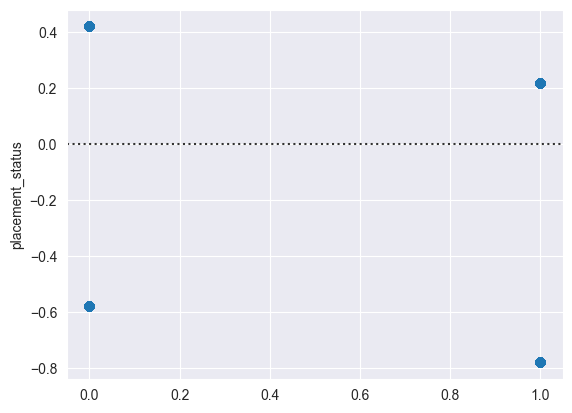

In [81]:
sns.residplot(x=y_pred_lr_cal, y=y_cal_test - y_pred_lr_cal)

In [82]:
lr.fit(x_train, y_cal_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [83]:
y_pred = lr.predict(x_test)
y_pred

array([1, 1, 0, ..., 0, 1, 1], shape=(20000,))

In [84]:
accuracy_score(y_cal_test, y_pred)

0.6072

In [85]:
print(y_cal.value_counts())

placement_status
1    68475
0    31525
Name: count, dtype: int64


In [86]:
from sklearn.metrics import classification_report
print(classification_report(y_cal_test, y_pred_lr_cal))

              precision    recall  f1-score   support

           0       0.42      0.64      0.51      6335
           1       0.78      0.59      0.67     13665

    accuracy                           0.61     20000
   macro avg       0.60      0.62      0.59     20000
weighted avg       0.67      0.61      0.62     20000



In [92]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()
model.fit(x_train, y_cal_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [93]:
y_gb_pred_cal = model.predict(x_test)
y_gb_pred_cal

array([1, 1, 1, ..., 1, 1, 1], shape=(20000,))

In [94]:
print(classification_report(y_cal_test, y_gb_pred_cal))

              precision    recall  f1-score   support

           0       0.58      0.10      0.17      6335
           1       0.70      0.97      0.81     13665

    accuracy                           0.69     20000
   macro avg       0.64      0.53      0.49     20000
weighted avg       0.66      0.69      0.61     20000



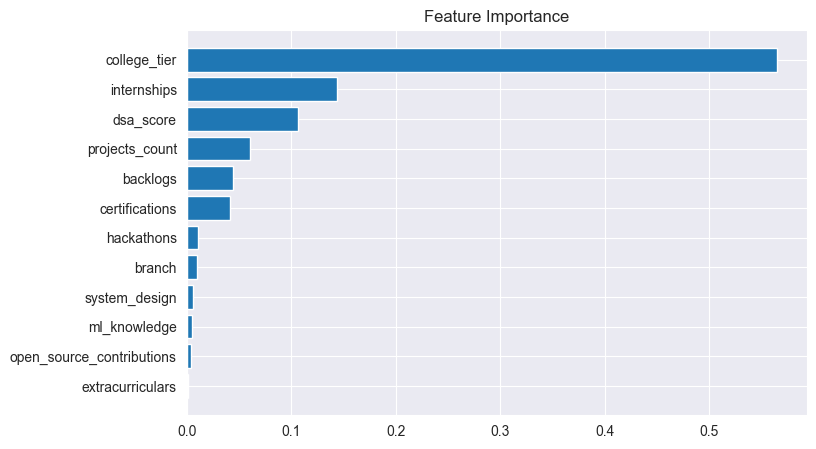

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = x.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

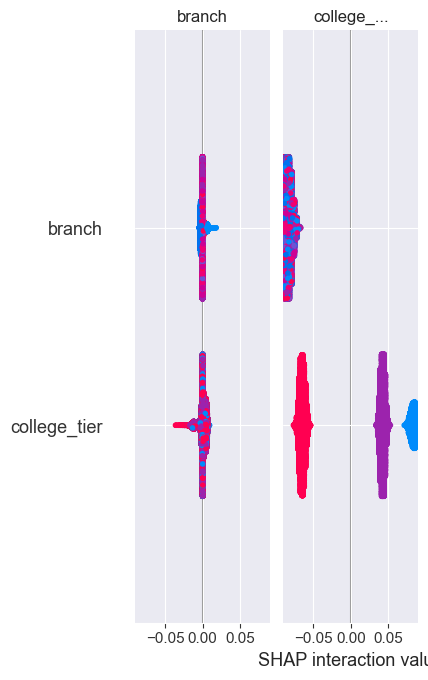

In [98]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_train)

shap.summary_plot(shap_values, x_train)
plt.show()